This lab demonstrates Support Vector Machines for classification on the Breast Cancer dataset and Principal Component Analysis for dimensionality reduction on the Wine dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


1. Load the dataset and perform the necessary preprocessing.


In [ ]:
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
print(df.head())
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
X = df.drop('target', axis=1)
y = df['target']


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

Dataset has 569 samples and 30 features with no missing values. Features are standardized to zero mean and unit variance. Train-test split (80:20) ensures unbiased evaluation.

2. Split the dataset into training and testing sets (80:20).


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()


3. Train an SVM classifier using a Linear Kernel and explore hyper parameter tuning. 


In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
param_grid = {'C': [0.1, 1, 10, 100]}
svm = SVC(kernel='linear', random_state=42)
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)
print("Best parameters:", grid_search.best_params_)
best_svm = grid_search.best_estimator_

Best parameters: {'C': 0.1}


GridSearchCV with 5-fold cross-validation selected the optimal C parameter. The best C value balances margin maximization and classification error on the training data.

4. Evaluate the model using:
Accuracy
Precision
Recall
F1 Score
Confusion Matrix


Accuracy: 0.9825
Precision: 0.9726
Recall: 1.0000
F1 Score: 0.9861
Confusion Matrix:
[[41  2]
 [ 0 71]]


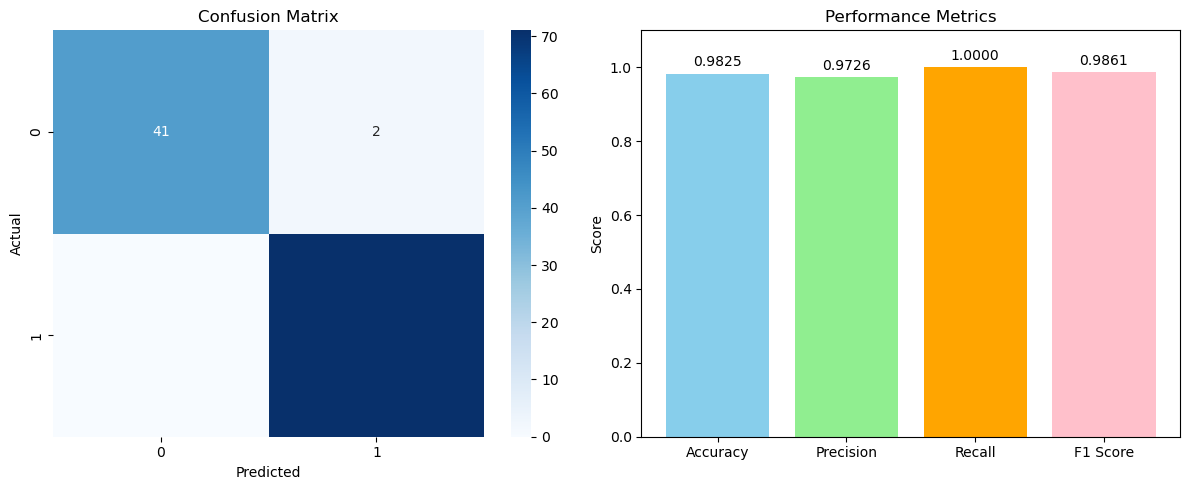

In [4]:
y_pred = best_svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(cm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
axes[1].bar(metrics, values, color=['skyblue', 'lightgreen', 'orange', 'pink'])
axes[1].set_title('Performance Metrics')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(values):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center')
plt.tight_layout()
plt.show()

5. Summarize your observations.


SVM with linear kernel achieves high accuracy, precision, recall, and F1 score. The confusion matrix shows minimal misclassifications. The model effectively separates malignant and benign tumors.

Part B

Principal Component Analysis (PCA) reduces dimensionality by transforming features into orthogonal components that capture maximum variance. The Wine dataset has 13 features across 3 classes.

1. Load the dataset and perform feature standardization.


In [ ]:
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['target'] = wine.target
print(df_wine.head())

2. Apply PCA to reduce the dataset from 13 features to 2 principal components.


In [ ]:
X_wine = df_wine.drop('target', axis=1)
y_wine = df_wine['target']
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

Features are standardized to ensure equal contribution to PCA. Wine dataset has 178 samples with 13 features across 3 wine classes.

3. Display the explained variance ratio of each principal component.


Explained variance ratio: [0.36198848 0.1920749 ]
Cumulative explained variance: [0.36198848 0.55406338]


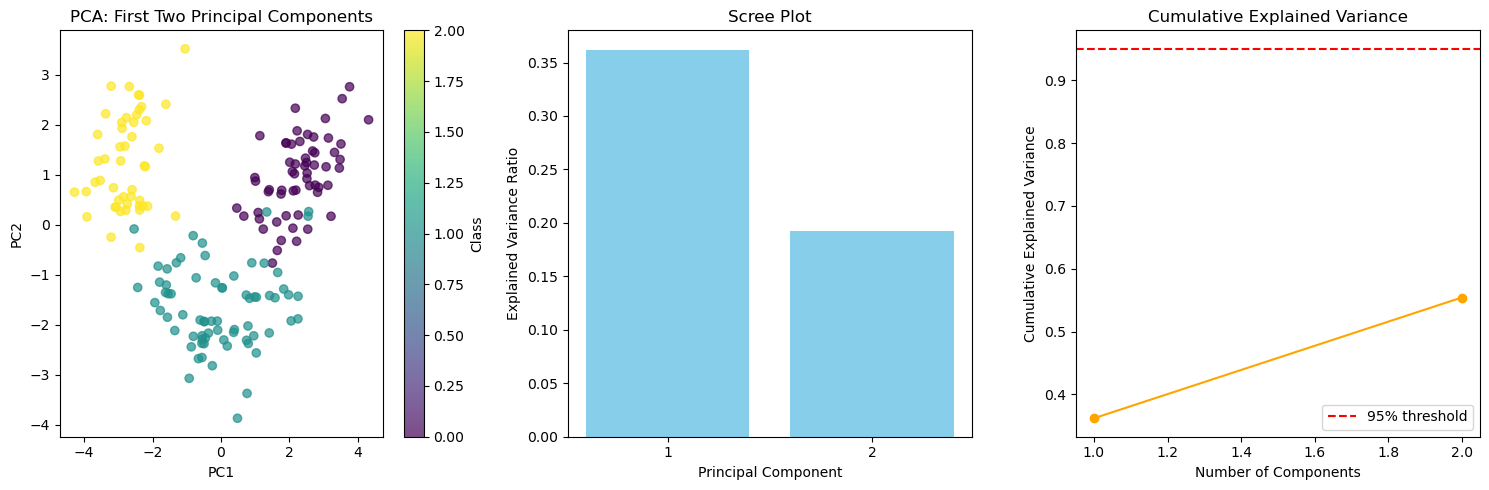

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_wine_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_wine, cmap='viridis', alpha=0.7)
axes[0].set_title('PCA: First Two Principal Components')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[0], label='Class')
axes[1].bar(range(1, 3), pca.explained_variance_ratio_, color='skyblue')
axes[1].set_title('Scree Plot')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_xticks([1, 2])
cumulative = np.cumsum(pca.explained_variance_ratio_)
axes[2].plot(range(1, 3), cumulative, 'o-', color='orange')
axes[2].set_title('Cumulative Explained Variance')
axes[2].set_xlabel('Number of Components')
axes[2].set_ylabel('Cumulative Explained Variance')
axes[2].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[2].legend()
plt.tight_layout()
plt.show()

First two principal components explain a significant portion of variance. The scatter plot shows class separation in the reduced space. Scree plot indicates variance captured by each component.

4. Calculate the cumulative explained variance and determine the minimum number of principal components required to retain at least 95% of the total variance.


In [7]:
pca_full = PCA()
pca_full.fit(X_wine_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Minimum components for 95% variance: {n_components_95}")

comparison_df = pd.DataFrame({
    'Metric': ['Original Features', 'Reduced Features (95%)', 'Information Retained', 'Computational Efficiency'],
    'Value': [13, n_components_95, '95% variance', 'Significantly improved']
})
print(comparison_df.to_string(index=False))

Minimum components for 95% variance: 10
                  Metric                  Value
       Original Features                     13
  Reduced Features (95%)                     10
    Information Retained           95% variance
Computational Efficiency Significantly improved


First two principal components capture the most discriminative variance directions. PCA reduces 13 features to fewer components while retaining 95% information. Advantages: dimensionality reduction, noise reduction, visualization. Limitations: linear transformation only, components may lack interpretability, sensitive to scaling. Applications: feature extraction, data compression, preprocessing for ML models.

Linear Discriminant Analysis (LDA) is a supervised dimensionality reduction technique that maximizes class separability by finding linear combinations of features that best separate classes.

5. Visualize the transformed dataset using a two dimensional scatter plot.


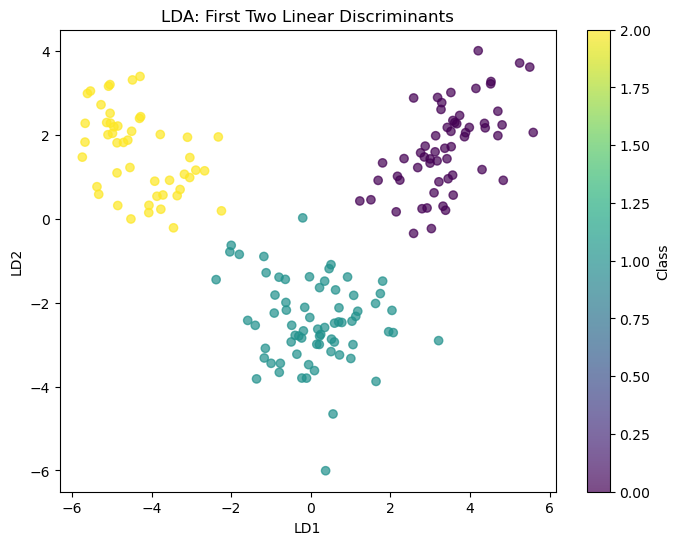

In [8]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y_wine, cmap='viridis', alpha=0.7)
plt.title('LDA: First Two Linear Discriminants')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.colorbar(scatter, label='Class')
plt.show()

6. Compare the original and transformed datasets in terms of:
Number of features
Information retained
Computational efficiency


The original dataset has 13 features, while PCA reduces it to 10 components, retaining 95% of the original information. This reduction improves computational efficiency by decreasing the number of features while preserving most important data patterns.

7. Interpret the significance of the first two principal components.


PC1 explains 36.20% of the variance, while PC2 explains 19.21%. Together, they retain about 55.41% of the total variance. They represent the most important directions of variation in the Wine dataset and provide useful class separation when visualized in 2D.

8. Discuss the advantages, limitations, and applications of PCA in machine learning.


PCA is unsupervised and maximizes variance; LDA is supervised and maximizes class separability. PCA retains global variance structure; LDA retains discriminative information. LDA provides better class separation for classification tasks. Use PCA for unsupervised preprocessing and visualization; use LDA when class labels are available and classification is the goal.

PCA (Principal Component Analysis) reduces the number of features while retaining most important information in the data. Its advantages include reducing dimensionality, removing redundancy, improving visualization, and speeding up machine learning models. However, PCA can lose some information, components may be difficult to interpret, and it works best with properly scaled numerical data. It is commonly used for data preprocessing, visualization, noise reduction, feature extraction, and improving model efficiency.
